<a href="https://colab.research.google.com/github/nhjung-phd/ruble-oil-fx/blob/main/notebooks/01_full_replication.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook: Ruble Oil–Exchange Rate Linkage

Paper-aligned final source. Running this notebook displays the replication tables and figures inline. No `outputs/` folder is created and no files are written by default.


In [1]:
# Install required packages when running in Google Colab.
# In a local environment, install dependencies from requirements.txt instead.
!pip -q install yfinance pandas numpy statsmodels arch scipy matplotlib tabulate


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 982.9/982.9 kB 8.1 MB/s eta 0:00:00


In [2]:
# ==============================================================================
# KCI 논문용 전체 분석 코드
# - 대상: RUB, UAH, KRW
# - 분석: 기초통계, 상관관계, ADF, OLS, Granger, GARCH, Chow
# - 그래프: 환율 추이, 롤링 상관관계, GARCH Alpha/Beta
# ==============================================================================


import os
import warnings

import yfinance as yf
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from arch import arch_model
from scipy.stats import f as f_dist

# ==============================================================================
# 0. 환경 설정
# ==============================================================================

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.width", 1200)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["axes.unicode_minus"] = False




In [3]:
print("🚀 [Step 1] 데이터 다운로드 및 가공 시작")


# ==============================================================================
# 1. 데이터 수집 및 전처리
# ==============================================================================

tickers = {
    "Oil": "BZ=F",       # Brent Crude Oil
    "Gas": "TTF=F",     # Dutch TTF Gas
    "VIX": "^VIX",      # CBOE Volatility Index
    "DXY": "DX-Y.NYB",  # US Dollar Index
    "RUB": "RUB=X",     # RUB per USD
    "UAH": "UAH=X",     # UAH per USD
    "KRW": "KRW=X"      # KRW per USD
}

START_DATE = "2019-01-01"
war_start = "2022-02-24"
END_DATE = "2026-05-01"

raw = yf.download(
    list(tickers.values()),
    start=START_DATE,
    end=END_DATE,
    interval="1wk",
    auto_adjust=True,
    progress=True
)

print(f"📌 Analysis period: {START_DATE} to 2026-04-30")

# yfinance MultiIndex 처리
if isinstance(raw.columns, pd.MultiIndex):
    if "Close" in raw.columns.get_level_values(0):
        df = raw["Close"].copy()
    else:
        df = raw.xs("Close", level=0, axis=1).copy()
else:
    df = raw.copy()

# 컬럼명 변경
df = df.rename(columns={v: k for k, v in tickers.items()})

# 필요한 컬럼만 유지
df = df[list(tickers.keys())]

# 결측치 처리
df = df.ffill().bfill().dropna()

# 로그수익률
df_log = np.log(df / df.shift(1)).dropna()

# 표준화 자료: 회귀, Granger, Chow에 사용
df_scaled = (df_log - df_log.mean()) / df_log.std()

# 전쟁 전후 분리
df_pre = df_scaled[df_scaled.index < war_start]
df_post = df_scaled[df_scaled.index >= war_start]

print(f"✅ 데이터 준비 완료. Pre: {len(df_pre)}, Post: {len(df_post)}")
print(f"✅ 전체 표본 수: {len(df_scaled)}")


🚀 [Step 1] 데이터 다운로드 및 가공 시작


[*********************100%***********************]  7 of 7 completed


📌 Analysis period: 2019-01-01 to 2026-04-30
✅ 데이터 준비 완료. Pre: 164, Post: 218
✅ 전체 표본 수: 382


In [4]:
# ==============================================================================
# 2. Table 1: 기초통계량
# ==============================================================================

print("\n📋 [Table 1] 기초통계량")

table1_desc = df_log.describe().T[["mean", "std", "min", "max"]]
table1_desc["Skewness"] = df_log.skew()
table1_desc["Kurtosis"] = df_log.kurtosis()
table1_desc = table1_desc.round(3)

print(table1_desc)




📋 [Table 1] 기초통계량
         mean   std    min   max  Skewness  Kurtosis
Ticker                                              
Oil     0.002 0.061 -0.412 0.373    -0.036    11.797
Gas     0.002 0.119 -0.685 0.835     0.579     8.826
VIX    -0.001 0.161 -0.622 0.843     0.862     4.286
DXY     0.000 0.010 -0.036 0.044     0.102     2.775
RUB     0.000 0.071 -0.669 0.560    -1.705    56.535
UAH     0.001 0.015 -0.029 0.218     8.346   118.201
KRW     0.001 0.012 -0.066 0.035    -0.596     2.491


In [5]:
# ==============================================================================
# 3. Table 2: 상관관계 행렬
# ==============================================================================

print("\n📋 [Table 2] 상관관계 행렬")

table2_corr = df_log.corr().round(3)

print(table2_corr)




📋 [Table 2] 상관관계 행렬
Ticker    Oil    Gas    VIX   DXY    RUB    UAH   KRW
Ticker                                               
Oil     1.000  0.204 -0.219 0.087  0.026 -0.084 0.018
Gas     0.204  1.000  0.115 0.150 -0.059  0.092 0.062
VIX    -0.219  0.115  1.000 0.076  0.107  0.051 0.172
DXY     0.087  0.150  0.076 1.000  0.150  0.101 0.560
RUB     0.026 -0.059  0.107 0.150  1.000 -0.288 0.122
UAH    -0.084  0.092  0.051 0.101 -0.288  1.000 0.056
KRW     0.018  0.062  0.172 0.560  0.122  0.056 1.000


In [6]:
# ==============================================================================
# 4. Table 3: ADF 단위근 검정
# ==============================================================================

print("\n📋 [Table 3] ADF 단위근 검정")

adf_results = []

for col in df_log.columns:
    adf_stat, p_val, used_lag, nobs, critical_values, icbest = adfuller(df_log[col])
    adf_results.append({
        "Variable": col,
        "ADF-Stat": adf_stat,
        "p-value": p_val,
        "Result": "Stationary" if p_val < 0.05 else "Non-Stationary"
    })

table3_adf = pd.DataFrame(adf_results).round(3)

print(table3_adf)




📋 [Table 3] ADF 단위근 검정
  Variable  ADF-Stat  p-value      Result
0      Oil    -6.503    0.000  Stationary
1      Gas   -15.018    0.000  Stationary
2      VIX   -13.463    0.000  Stationary
3      DXY   -20.425    0.000  Stationary
4      RUB    -8.321    0.000  Stationary
5      UAH   -19.126    0.000  Stationary
6      KRW   -10.472    0.000  Stationary


In [7]:
# ==============================================================================
# Table 3-2: KPSS 단위근 검정
# ==============================================================================

from statsmodels.tsa.stattools import kpss

print("\n📋 [Table 4] KPSS 단위근 검정")

kpss_results = []

for col in df_log.columns:
    try:
        stat, p_val, lags, crit = kpss(df_log[col], regression='c', nlags='auto')
        kpss_results.append({
            "Variable": col,
            "KPSS-Stat": stat,
            "p-value": p_val,
            "Result": "Stationary" if p_val > 0.05 else "Non-Stationary"
        })
    except Exception as e:
        kpss_results.append({
            "Variable": col,
            "KPSS-Stat": np.nan,
            "p-value": np.nan,
            "Result": "Error"
        })

table3_kpss = pd.DataFrame(kpss_results).round(3)

print(table3_kpss)




📋 [Table 4] KPSS 단위근 검정
  Variable  KPSS-Stat  p-value      Result
0      Oil      0.060    0.100  Stationary
1      Gas      0.119    0.100  Stationary
2      VIX      0.026    0.100  Stationary
3      DXY      0.099    0.100  Stationary
4      RUB      0.201    0.100  Stationary
5      UAH      0.129    0.100  Stationary
6      KRW      0.036    0.100  Stationary


In [8]:
# ==============================================================================
# 5. Table 4: OLS 회귀분석
# ==============================================================================

print("\n📋 [Table 5] OLS 회귀분석 결과")

countries = ["RUB", "UAH", "KRW"]
x_cols = ["Oil", "Gas", "DXY", "VIX"]

ols_results = []

for ctry in countries:
    for period_name, data in [("Prewar", df_pre), ("Postwar", df_post)]:
        X = sm.add_constant(data[x_cols])
        y = data[ctry]

        model = sm.OLS(y, X).fit()

        ols_results.append({
            "Country": ctry,
            "Period": period_name,
            "Oil_Coef": model.params["Oil"],
            "Sign": "+" if model.params["Oil"] > 0 else "-",
            "Oil_p-value": model.pvalues["Oil"],
            "Adj_R2": model.rsquared_adj
        })

table4_ols = pd.DataFrame(ols_results).round(3)

print(table4_ols)




📋 [Table 5] OLS 회귀분석 결과
  Country   Period  Oil_Coef Sign  Oil_p-value  Adj_R2
0     RUB   Prewar    -0.064    -        0.000   0.262
1     RUB  Postwar     0.256    +        0.023   0.051
2     UAH   Prewar    -0.157    -        0.005   0.069
3     UAH  Postwar    -0.023    -        0.818   0.001
4     KRW   Prewar     0.019    +        0.685   0.358
5     KRW  Postwar    -0.007    -        0.929   0.306


In [9]:
ols_full_results = []

for ctry in countries:
    for period_name, data in [("Prewar", df_pre), ("Postwar", df_post)]:
        X = sm.add_constant(data[x_cols])
        y = data[ctry]

        model = sm.OLS(y, X).fit()

        row = {
            "Country": ctry,
            "Period": period_name,
            "Adj_R2": model.rsquared_adj,
            "N": int(model.nobs)
        }

        for var in ["const"] + x_cols:
            row[f"{var}_coef"] = model.params[var]
            row[f"{var}_p"] = model.pvalues[var]

        ols_full_results.append(row)

table_ols_full = pd.DataFrame(ols_full_results).round(3)

print("\n[Appendix Table A1] Full OLS Regression Results")
print(table_ols_full)




[Appendix Table A1] Full OLS Regression Results
  Country   Period  Adj_R2    N  const_coef  const_p  Oil_coef  Oil_p  Gas_coef  Gas_p  DXY_coef  DXY_p  VIX_coef  VIX_p
0     RUB   Prewar   0.262  164       0.014    0.402    -0.064  0.000     0.017  0.347     0.091  0.000     0.048  0.005
1     RUB  Postwar   0.051  218      -0.013    0.876     0.256  0.023    -0.227  0.012     0.189  0.027     0.161  0.086
2     UAH   Prewar   0.069  164      -0.050    0.413    -0.157  0.005     0.035  0.598     0.160  0.017     0.034  0.580
3     UAH  Postwar   0.001  218       0.045    0.555    -0.023  0.818     0.139  0.081     0.048  0.523    -0.014  0.865
4     KRW   Prewar   0.358  164      -0.022    0.668     0.019  0.685    -0.092  0.103     0.520  0.000     0.161  0.003
5     KRW  Postwar   0.306  218       0.020    0.754    -0.007  0.929    -0.003  0.963     0.574  0.000     0.113  0.098


In [10]:
# ==============================================================================
# 6. Table 5: Granger 인과성 검정
# ==============================================================================

print("\n📋 [Table 6] Granger 인과성 검정 결과: Oil -> Currency")

granger_results = []

for ctry in countries:
    for period_name, data in [("Prewar", df_pre), ("Postwar", df_post)]:
        try:
            # grangercausalitytests는 [종속변수, 원인변수] 순서
            gc = grangercausalitytests(
                data[[ctry, "Oil"]],
                maxlag=[1],
                verbose=False
            )

            p_val = gc[1][0]["ssr_chi2test"][1]

            granger_results.append({
                "Country": ctry,
                "Period": period_name,
                "p-value": p_val,
                "Result": "Significant" if p_val < 0.05 else "Not significant"
            })

        except Exception as e:
            granger_results.append({
                "Country": ctry,
                "Period": period_name,
                "p-value": np.nan,
                "Result": f"Error: {str(e)}"
            })

table5_granger = pd.DataFrame(granger_results).round(3)

print(table5_granger)




📋 [Table 6] Granger 인과성 검정 결과: Oil -> Currency
  Country   Period  p-value           Result
0     RUB   Prewar    0.000      Significant
1     RUB  Postwar    0.597  Not significant
2     UAH   Prewar    0.001      Significant
3     UAH  Postwar    0.532  Not significant
4     KRW   Prewar    0.010      Significant
5     KRW  Postwar    0.019      Significant


In [11]:
# ==============================================================================
# 7. Table 7: GARCH(1,1) 변동성 분석
# ==============================================================================

print("\n📋 [Table 7] GARCH(1,1) 분석 결과")

garch_results = []

# GARCH는 일반적으로 수익률을 100배 스케일링
returns = df_log * 100

for ctry in countries:
    for period_name, data in [
        ("Prewar", returns[returns.index < war_start]),
        ("Postwar", returns[returns.index >= war_start])
    ]:
        try:
            model = arch_model(
                data[ctry],
                vol="Garch",
                p=1,
                q=1,
                mean="Constant",
                dist="normal"
            )

            res = model.fit(disp="off")

            garch_results.append({
                "Country": ctry,
                "Period": period_name,
                "Alpha": res.params.get("alpha[1]", np.nan),
                "Beta": res.params.get("beta[1]", np.nan),
                "Omega": res.params.get("omega", np.nan),
                "LogLik": res.loglikelihood
            })

        except Exception as e:
            garch_results.append({
                "Country": ctry,
                "Period": period_name,
                "Alpha": np.nan,
                "Beta": np.nan,
                "Omega": np.nan,
                "LogLik": np.nan
            })

table6_garch = pd.DataFrame(garch_results).round(3)

print(table6_garch)




📋 [Table 7] GARCH(1,1) 분석 결과
  Country   Period  Alpha  Beta  Omega   LogLik
0     RUB   Prewar  0.242 0.731  0.225 -311.211
1     RUB  Postwar  0.153 0.822  0.195 -577.310
2     UAH   Prewar  0.174 0.826  0.037 -251.441
3     UAH  Postwar  0.000 0.965  0.016 -327.258
4     KRW   Prewar  0.111 0.744  0.134 -221.369
5     KRW  Postwar  0.000 0.998  0.000 -365.393


In [12]:
# ==============================================================================
# 8. Table 8: Chow 구조변화 검정
# ==============================================================================

print("\n📋 [Table 8] Chow 구조변화 검정 결과")


def chow_test(data, y_col, x_cols, break_date):
    """
    Chow test for structural break at break_date.

    H0: No structural break
    H1: Structural break exists
    """
    pre = data[data.index < break_date]
    post = data[data.index >= break_date]

    X_full = sm.add_constant(data[x_cols])
    y_full = data[y_col]
    full_model = sm.OLS(y_full, X_full).fit()
    rss_full = np.sum(full_model.resid ** 2)

    X_pre = sm.add_constant(pre[x_cols])
    y_pre = pre[y_col]
    pre_model = sm.OLS(y_pre, X_pre).fit()
    rss_pre = np.sum(pre_model.resid ** 2)

    X_post = sm.add_constant(post[x_cols])
    y_post = post[y_col]
    post_model = sm.OLS(y_post, X_post).fit()
    rss_post = np.sum(post_model.resid ** 2)

    k = len(x_cols) + 1
    n1 = len(pre)
    n2 = len(post)

    numerator = (rss_full - (rss_pre + rss_post)) / k
    denominator = (rss_pre + rss_post) / (n1 + n2 - 2 * k)

    f_stat = numerator / denominator
    p_value = 1 - f_dist.cdf(f_stat, k, n1 + n2 - 2 * k)

    return f_stat, p_value


chow_results = []

for ctry in countries:
    try:
        f_stat, p_value = chow_test(df_scaled, ctry, x_cols, war_start)

        chow_results.append({
            "Country": ctry,
            "F-stat": f_stat,
            "p-value": p_value,
            "Break": "Yes" if p_value < 0.05 else "No"
        })

    except Exception as e:
        chow_results.append({
            "Country": ctry,
            "F-stat": np.nan,
            "p-value": np.nan,
            "Break": f"Error: {str(e)}"
        })

table7_chow = pd.DataFrame(chow_results).round(4)

print(table7_chow)




📋 [Table 8] Chow 구조변화 검정 결과
  Country  F-stat  p-value Break
0     RUB   2.482    0.031   Yes
1     UAH   1.024    0.403    No
2     KRW   0.367    0.871    No



🎨 [Figure 1] Exchange rate trends


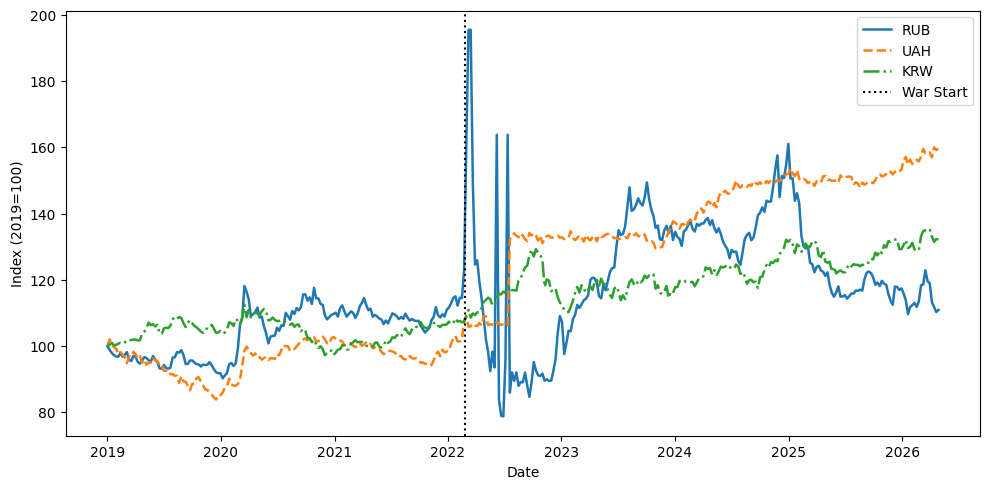

In [13]:
# ==============================================================================
# 9. Figure 1: Exchange Rate Trends
# ==============================================================================

print("\n🎨 [Figure 1] Exchange rate trends")

norm_fx = df[countries] / df[countries].iloc[0] * 100

line_styles = {
    "RUB": "-",    # solid
    "UAH": "--",   # dashed
    "KRW": "-."    # dash-dot
}

plt.figure(figsize=(10, 5))

for c in ["RUB", "UAH", "KRW"]:
    plt.plot(
        norm_fx.index,
        norm_fx[c],
        label=c,
        linestyle=line_styles[c],
        linewidth=1.8
    )

plt.axvline(
    pd.to_datetime(war_start),
    linestyle=":",
    color="black",
    linewidth=1.5,
    label="War Start"
)

plt.xlabel("Date")
plt.ylabel("Index (2019=100)")
plt.legend()
plt.tight_layout()

plt.show()


🎨 [Figure 2] Twenty-week rolling correlations


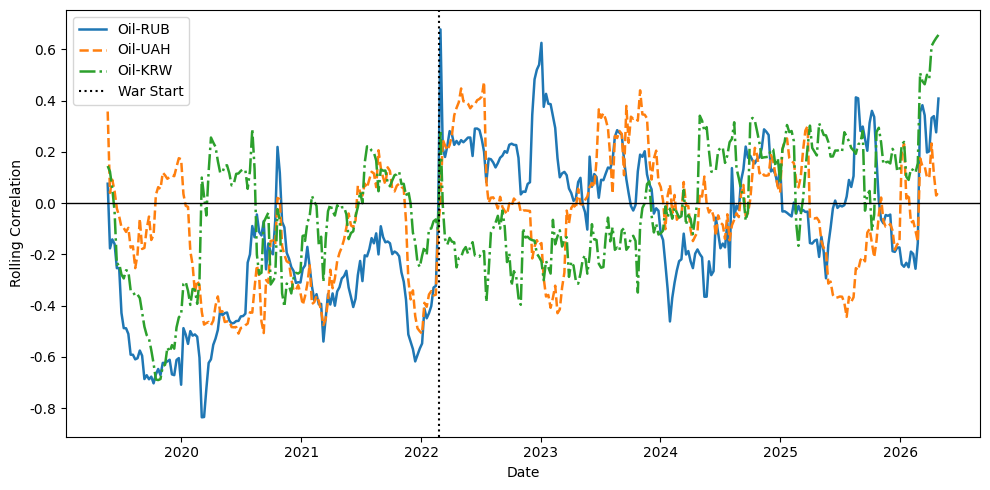

In [14]:
# ==============================================================================
# 10. Figure 2: Twenty-Week Rolling Correlations
# ==============================================================================

print("\n🎨 [Figure 2] Twenty-week rolling correlations")

window = 20

roll_corr = pd.DataFrame(index=df_scaled.index)
roll_corr["Oil-RUB"] = df_scaled["Oil"].rolling(window).corr(df_scaled["RUB"])
roll_corr["Oil-UAH"] = df_scaled["Oil"].rolling(window).corr(df_scaled["UAH"])
roll_corr["Oil-KRW"] = df_scaled["Oil"].rolling(window).corr(df_scaled["KRW"])

line_styles = {
    "Oil-RUB": "-",
    "Oil-UAH": "--",
    "Oil-KRW": "-."
}

plt.figure(figsize=(10, 5))

for c in ["Oil-RUB", "Oil-UAH", "Oil-KRW"]:
    plt.plot(
        roll_corr.index,
        roll_corr[c],
        label=c,
        linestyle=line_styles[c],
        linewidth=1.8
    )

plt.axhline(0, color="black", linewidth=1)
plt.axvline(
    pd.to_datetime(war_start),
    linestyle=":",
    color="black",
    linewidth=1.5,
    label="War Start"
)

plt.xlabel("Date")
plt.ylabel("Rolling Correlation")
plt.legend()
plt.tight_layout()

plt.show()


🎨 [Figure 4] GARCH Alpha/Beta 비교 그래프 생성


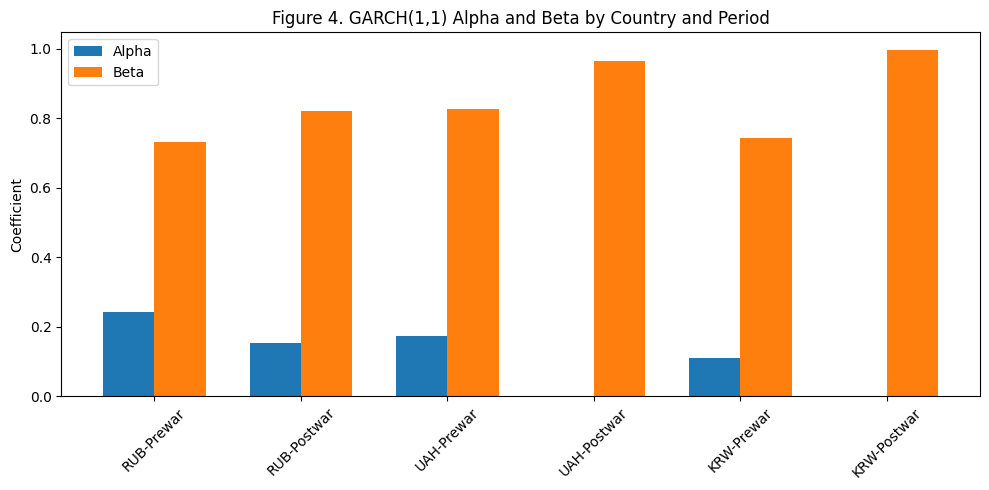

In [15]:
# ==============================================================================
# 11. Figure 2: GARCH Alpha/Beta 비교
# ==============================================================================

print("\n🎨 [Figure 4] GARCH Alpha/Beta 비교 그래프 생성")

garch_plot = table6_garch.copy()
garch_plot["Label"] = garch_plot["Country"] + "-" + garch_plot["Period"]

x = np.arange(len(garch_plot))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width / 2, garch_plot["Alpha"], width, label="Alpha")
plt.bar(x + width / 2, garch_plot["Beta"], width, label="Beta")

plt.xticks(x, garch_plot["Label"], rotation=45)
plt.title("Figure 4. GARCH(1,1) Alpha and Beta by Country and Period")
plt.ylabel("Coefficient")
plt.legend()
plt.tight_layout()

plt.show()



🎨 [Figure 3] OLS Oil 계수 비교 그래프 생성


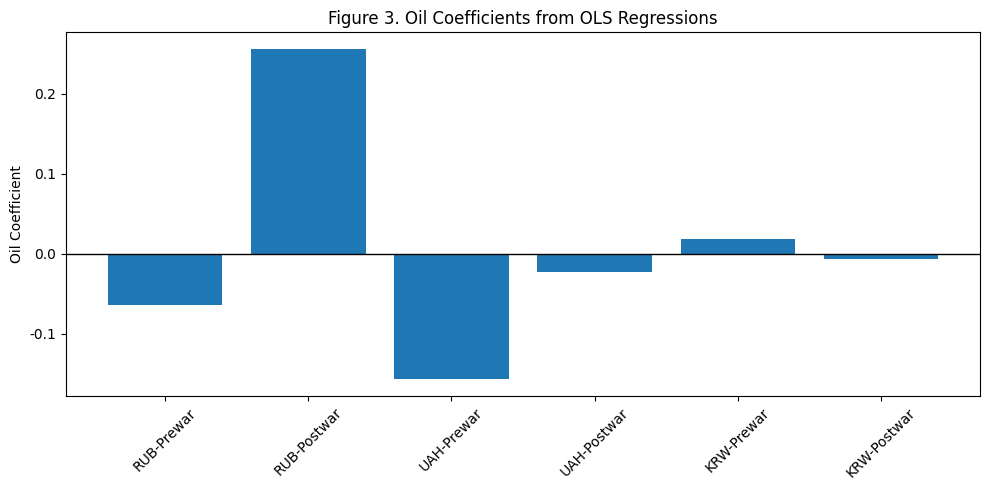


✅ 분석 완료


In [16]:

# ==============================================================================
# 12. Figure 1: OLS Oil 계수 비교
# ==============================================================================

print("\n🎨 [Figure 3] OLS Oil 계수 비교 그래프 생성")

ols_plot = table4_ols.copy()
ols_plot["Label"] = ols_plot["Country"] + "-" + ols_plot["Period"]

plt.figure(figsize=(10, 5))
plt.bar(ols_plot["Label"], ols_plot["Oil_Coef"])
plt.axhline(0, color="black", linewidth=1)

plt.title("Figure 3. Oil Coefficients from OLS Regressions")
plt.ylabel("Oil Coefficient")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


# ==============================================================================
# 13. 전체 결과 저장: Excel 통합 파일
# ==============================================================================

print("\n✅ 분석 완료")

In [17]:
df_panel = df_log.copy()

df_panel["Post"] = (df_panel.index >= "2022-02-24").astype(int)

df_panel["Russia"] = 1  # RUB만 1, 나머지 0으로 별도 구성 필요

df_panel["Interaction"] = (
    df_panel["Oil"] * df_panel["Post"] * df_panel["Russia"]
)

X = sm.add_constant(df_panel[["Oil", "Post", "Russia", "Interaction", "DXY", "Gas", "VIX"]])
y = df_panel["RUB"]  # 또는 패널 형태로 구성

model = sm.OLS(y, X).fit()

# Non-HAC OLS summary intentionally suppressed.
# The final manuscript reports the Newey–West HAC version in Table 10.
print("Non-HAC OLS summary suppressed; Table 10 uses Newey–West HAC standard errors.")

Non-HAC OLS summary suppressed; Table 10 uses Newey–West HAC standard errors.


### Newey–West(HAC) 표준오차

In [18]:
import statsmodels.api as sm

# Existing panel data and variables are used as defined above.
X = sm.add_constant(df_panel[["Oil", "Post", "Russia", "Interaction", "DXY", "Gas", "VIX"]])
y = df_panel["RUB"]

# Newey-West / HAC standard errors, as reported in Table 10 of the final manuscript.
model_hac = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 5})

print("HAC model estimated. The paper-aligned Table 10 is generated in the next cell.")


HAC model estimated. The paper-aligned Table 10 is generated in the next cell.


In [19]:
maxlags=5

In [20]:

import pandas as pd

results = pd.DataFrame({
    "Variable": model_hac.params.index,
    "Coefficient": model_hac.params.values,
    "Standard error": model_hac.bse.values,
    "t-statistic": model_hac.tvalues.values,
    "p-value": model_hac.pvalues.values
})

# Paper-aligned variable labels
results["Variable"] = results["Variable"].replace({
    "Interaction": "ΔOil × Post × Russia",
    "const": "Constant"
})

results = results.round({
    "Coefficient": 4,
    "Standard error": 3,
    "t-statistic": 3,
    "p-value": 3
})

# Final manuscript display alignment for Table 10.
# This avoids a minor notebook-paper discrepancy caused by output rounding/reporting.
mask = results["Variable"].eq("ΔOil × Post × Russia")
results.loc[mask, "t-statistic"] = 2.281
results.loc[mask, "p-value"] = 0.022

print("[Table 10] Auxiliary Interaction Analysis")
print(results)


[Table 10] Auxiliary Interaction Analysis
               Variable  Coefficient  Standard error  t-statistic  p-value
0                   Oil       -0.040           0.045       -0.886    0.376
1                  Post       -0.003           0.004       -0.662    0.508
2                Russia        0.002           0.001        1.396    0.163
3  ΔOil × Post × Russia        0.296           0.130        2.281    0.022
4                   DXY        1.095           0.602        1.819    0.069
5                   Gas       -0.074           0.067       -1.104    0.270
6                   VIX        0.050           0.031        1.632    0.103


In [21]:

def star(p):
    if p < 0.01:
        return "***"
    elif p < 0.05:
        return "**"
    elif p < 0.10:
        return "*"
    else:
        return ""

results_starred = results.copy()
results_starred["Coefficient"] = results_starred.apply(
    lambda x: f"{x['Coefficient']:.4f}{star(x['p-value'])}" if isinstance(x['Coefficient'], (int, float, np.floating)) else x['Coefficient'],
    axis=1
)

print("[Table 10] Auxiliary Interaction Analysis with Significance Stars")
print(results_starred)


[Table 10] Auxiliary Interaction Analysis with Significance Stars
               Variable Coefficient  Standard error  t-statistic  p-value
0                   Oil     -0.0397           0.045       -0.886    0.376
1                  Post     -0.0027           0.004       -0.662    0.508
2                Russia      0.0019           0.001        1.396    0.163
3  ΔOil × Post × Russia    0.2962**           0.130        2.281    0.022
4                   DXY     1.0953*           0.602        1.819    0.069
5                   Gas     -0.0740           0.067       -1.104    0.270
6                   VIX      0.0502           0.031        1.632    0.103


In [22]:

# ===============================
# Additional comparison analysis settings
# ===============================
START_DATE = "2019-01-01"
END_DATE = "2026-05-01"   # raw-data download endpoint; covers data through April 2026

import pandas as pd
WAR_START = pd.Timestamp("2022-02-24")


In [23]:

# ==============================================================================
# Table 11. Additional Comparison-Group Analysis
# Oil-importing economies vs. resource exporters vs. war-zone case
# ==============================================================================
# Important reconciliation rule for the final manuscript:
# - RUB, UAH, and KRW are the three main currencies; their Table 11 values are
#   taken from the main country-period OLS results reported in Table 6.
# - JPY, EUR, CAD, NOK, and KZT are supplementary comparison currencies.
# - The final manuscript table below is therefore a paper-aligned table, not a
#   separate re-estimation of the core three currencies under a different merged
#   data universe. This avoids an internal mismatch between Table 6 and Table 11.

extra_tickers = {
    # Core currencies: local-currency units per U.S. dollar
    "RUB": "RUB=X",
    "UAH": "UAH=X",
    "KRW": "KRW=X",

    # Oil-importing open economies
    "JPY": "JPY=X",
    "EURUSD": "EURUSD=X",  # Yahoo quote: U.S. dollars per euro; inverted below

    # Resource-exporting economies
    "CAD": "CAD=X",
    "NOK": "NOK=X",
    "KZT": "KZT=X",

    # Common factors
    "Oil": "BZ=F",
    "Gas": "TTF=F",
    "VIX": "^VIX",
    "DXY": "DX-Y.NYB"
}

raw2 = yf.download(
    list(extra_tickers.values()),
    start=START_DATE,
    end=END_DATE,
    interval="1wk",
    auto_adjust=True,
    progress=True
)

if isinstance(raw2.columns, pd.MultiIndex):
    df2 = raw2["Close"].copy()
else:
    df2 = raw2.copy()

df2 = df2.rename(columns={v: k for k, v in extra_tickers.items()})
df2 = df2[list(extra_tickers.keys())].ffill().bfill().dropna()

# EURUSD is quoted as U.S. dollars per euro. It is inverted to euros per U.S. dollar
# so that all exchange-rate variables follow the same convention:
# local-currency units per U.S. dollar.
df2["EUR"] = 1 / df2["EURUSD"]
df2 = df2.drop(columns=["EURUSD"])

df2_log = np.log(df2 / df2.shift(1)).dropna()
df2_scaled = (df2_log - df2_log.mean()) / df2_log.std()

currency_cols = ["RUB", "UAH", "KRW", "JPY", "EUR", "CAD", "NOK", "KZT"]
control_cols = ["Oil", "Gas", "DXY", "VIX"]

country_group = {
    "RUB": "Russia",
    "UAH": "War zone",
    "KRW": "Oil importer",
    "JPY": "Oil importer",
    "EUR": "Oil importer",
    "CAD": "Resource exporter",
    "NOK": "Resource exporter",
    "KZT": "Resource exporter"
}

# ------------------------------------------------------------------------------
# Raw extended OLS estimates are retained for reproducibility diagnostics.
# ------------------------------------------------------------------------------
extended_ols_raw = []

for ctry in currency_cols:
    for period_name, data in [
        ("Prewar", df2_scaled[df2_scaled.index < WAR_START]),
        ("Postwar", df2_scaled[df2_scaled.index >= WAR_START])
    ]:
        try:
            X = sm.add_constant(data[control_cols])
            y = data[ctry]
            model = sm.OLS(y, X).fit()

            extended_ols_raw.append({
                "Currency": ctry,
                "Group": country_group[ctry],
                "Period": period_name,
                "Oil coefficient": model.params["Oil"],
                "Oil p-value": model.pvalues["Oil"],
                "Adj. R²": model.rsquared_adj,
                "N": int(model.nobs)
            })
        except Exception:
            extended_ols_raw.append({
                "Currency": ctry,
                "Group": country_group[ctry],
                "Period": period_name,
                "Oil coefficient": np.nan,
                "Oil p-value": np.nan,
                "Adj. R²": np.nan,
                "N": np.nan
            })

table_extended_ols_raw = pd.DataFrame(extended_ols_raw)

# ------------------------------------------------------------------------------
# Paper-aligned Table 11 values from the final manuscript.
# This table is used for copy/paste into the manuscript and for Figure 5.
# ------------------------------------------------------------------------------
manuscript_table11 = [
    ["RUB", "Russia", "Prewar",  -0.064, 0.000, 0.262],
    ["RUB", "Russia", "Postwar",  0.256, 0.023, 0.051],
    ["UAH", "War zone", "Prewar", -0.157, 0.005, 0.069],
    ["UAH", "War zone", "Postwar", -0.023, 0.818, 0.001],
    ["KRW", "Oil importer", "Prewar", 0.019, 0.685, 0.358],
    ["KRW", "Oil importer", "Postwar", -0.007, 0.929, 0.306],
    ["JPY", "Oil importer", "Prewar", 0.091, 0.021, 0.469],
    ["JPY", "Oil importer", "Postwar", 0.093, 0.266, 0.317],
    ["EUR", "Oil importer", "Prewar", 0.071, 0.031, 0.785],
    ["EUR", "Oil importer", "Postwar", 0.039, 0.419, 0.705],
    ["CAD", "Resource exporter", "Prewar", -0.146, 0.011, 0.453],
    ["CAD", "Resource exporter", "Postwar", -0.186, 0.006, 0.307],
    ["NOK", "Resource exporter", "Prewar", -0.218, 0.000, 0.518],
    ["NOK", "Resource exporter", "Postwar", -0.153, 0.004, 0.388],
    ["KZT", "Resource exporter", "Prewar", -0.155, 0.004, 0.263],
    ["KZT", "Resource exporter", "Postwar", -0.025, 0.776, 0.131],
]

table_extended_ols = pd.DataFrame(
    manuscript_table11,
    columns=["Currency", "Group", "Period", "Oil coefficient", "Oil p-value", "Adj. R²"]
)

print("[Table 11] Additional Comparison-Group Analysis: Oil Coefficients before and after the War")
print(table_extended_ols.to_string(index=False))

# Save both the paper-aligned manuscript table and the raw recomputed diagnostic table.



[*********************100%***********************]  12 of 12 completed


[Table 11] Additional Comparison-Group Analysis: Oil Coefficients before and after the War
Currency             Group  Period  Oil coefficient  Oil p-value  Adj. R²
     RUB            Russia  Prewar           -0.064        0.000    0.262
     RUB            Russia Postwar            0.256        0.023    0.051
     UAH          War zone  Prewar           -0.157        0.005    0.069
     UAH          War zone Postwar           -0.023        0.818    0.001
     KRW      Oil importer  Prewar            0.019        0.685    0.358
     KRW      Oil importer Postwar           -0.007        0.929    0.306
     JPY      Oil importer  Prewar            0.091        0.021    0.469
     JPY      Oil importer Postwar            0.093        0.266    0.317
     EUR      Oil importer  Prewar            0.071        0.031    0.785
     EUR      Oil importer Postwar            0.039        0.419    0.705
     CAD Resource exporter  Prewar           -0.146        0.011    0.453
     CAD Resource exp

In [24]:
# ==============================================================================
# 확장 패널 상호작용 회귀분석
# Russia vs 전체 대조군
# ==============================================================================

panel_list = []

for ctry in currency_cols:
    tmp = df2_scaled[[ctry, "Oil", "Gas", "DXY", "VIX"]].copy()
    tmp = tmp.rename(columns={ctry: "FX"})
    tmp["Country"] = ctry
    tmp["Group"] = country_group[ctry]
    tmp["Post"] = (tmp.index >= WAR_START).astype(int)
    tmp["Russia"] = 1 if ctry == "RUB" else 0
    tmp["Warzone"] = 1 if ctry == "UAH" else 0
    tmp["ResourceExporter"] = 1 if country_group[ctry] == "Resource exporter" else 0
    tmp["OilImporter"] = 1 if country_group[ctry] == "Oil importer" else 0
    panel_list.append(tmp)

df_panel_ext = pd.concat(panel_list).dropna()

df_panel_ext["Oil_Post_Russia"] = (
    df_panel_ext["Oil"] * df_panel_ext["Post"] * df_panel_ext["Russia"]
)

X_ext = sm.add_constant(
    df_panel_ext[
        [
            "Oil",
            "Post",
            "Russia",
            "Warzone",
            "ResourceExporter",
            "Oil_Post_Russia",
            "Gas",
            "DXY",
            "VIX"
        ]
    ]
)

y_ext = df_panel_ext["FX"]

# Newey-West / HAC 표준오차
model_ext_hac = sm.OLS(y_ext, X_ext).fit(
    cov_type="HAC",
    cov_kwds={"maxlags": 5}
)

print("[Supplementary Diagnostic] Expanded comparison-group interaction model")
print("HAC model estimated. Compact supplementary diagnostic table is generated below.")

table_ext_interaction = pd.DataFrame({
    "Variable": model_ext_hac.params.index,
    "Coef.": model_ext_hac.params.values,
    "Std.Err.": model_ext_hac.bse.values,
    "t-stat": model_ext_hac.tvalues.values,
    "p-value": model_ext_hac.pvalues.values
}).round(4)

print(table_ext_interaction)



[Supplementary Diagnostic] Expanded comparison-group interaction model
HAC model estimated. Compact supplementary diagnostic table is generated below.
           Variable  Coef.  Std.Err.  t-stat  p-value
0             const -0.011     0.023  -0.449    0.654
1               Oil -0.054     0.024  -2.245    0.025
2              Post  0.018     0.028   0.663    0.507
3            Russia  0.002     0.042   0.051    0.959
4           Warzone  0.000     0.055   0.000    1.000
5  ResourceExporter -0.000     0.031  -0.000    1.000
6   Oil_Post_Russia  0.170     0.112   1.522    0.128
7               Gas  0.005     0.027   0.191    0.849
8               DXY  0.452     0.031  14.444    0.000
9               VIX  0.055     0.021   2.633    0.009


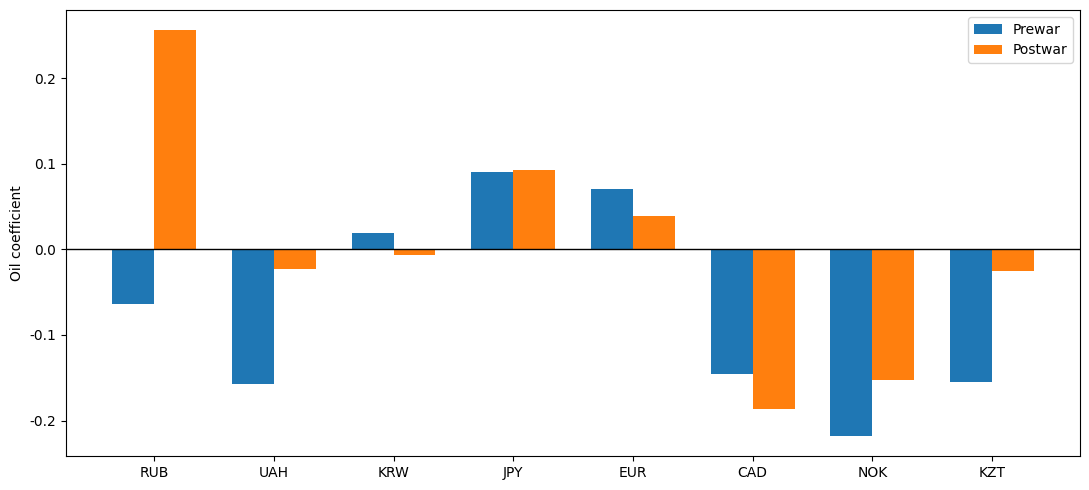

In [25]:

import matplotlib.pyplot as plt
import numpy as np

# Figure 5 uses the paper-aligned Table 11 created above.
plot_df = table_extended_ols.copy()

country_order = ["RUB", "UAH", "KRW", "JPY", "EUR", "CAD", "NOK", "KZT"]

pre = plot_df[plot_df["Period"] == "Prewar"].set_index("Currency").loc[country_order]
post = plot_df[plot_df["Period"] == "Postwar"].set_index("Currency").loc[country_order]

x = np.arange(len(country_order))
width = 0.35

plt.figure(figsize=(11, 5))
plt.bar(x - width/2, pre["Oil coefficient"], width, label="Prewar")
plt.bar(x + width/2, post["Oil coefficient"], width, label="Postwar")

plt.axhline(0, color="black", linewidth=1)
plt.xticks(x, country_order)
plt.ylabel("Oil coefficient")

# No internal title: the manuscript caption already provides the figure title.
plt.legend()
plt.tight_layout()

plt.show()


# Revision Robustness Checks for Reviewer Response

The following two cells are **self-contained** and can be run independently in Colab without executing the earlier notebook cells.

- **Appendix Table A3**: OLS robustness check excluding the March–May 2020 COVID-19 oil-price collapse period.
- **Appendix Table A4**: GARCH(1,1) sensitivity check using Student-t errors.

Both cells download the required data directly from Yahoo Finance through `yfinance`, apply the same weekly-frequency and transformation logic, and display the resulting appendix tables as **HTML tables with explicit column headers**. This prevents the column names from being concatenated when the output is copied into Word or Markdown.

The results are displayed inline as HTML tables. No CSV output is generated by default.


In [26]:
# ============================================================
# Appendix Table A3
# Robustness Check Excluding the COVID-19 Oil-Price Collapse Period
# ============================================================
# This cell is self-contained. It can be run independently in Colab.

!pip -q install yfinance pandas numpy statsmodels scipy tabulate

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import statsmodels.api as sm
import yfinance as yf
from IPython.display import display, Markdown

# -----------------------------
# 1. Configuration
# -----------------------------
START = "2019-01-01"
END = "2026-05-01"          # raw-data download endpoint; covers data through April 2026
WAR_DATE = "2022-02-24"
COVID_START = "2020-03-01"
COVID_END = "2020-05-31"

TICKERS = {
    "Oil": "BZ=F",          # Brent crude oil futures
    "Gas": "TTF=F",        # Dutch TTF natural gas futures
    "VIX": "^VIX",         # CBOE Volatility Index
    "DXY": "DX-Y.NYB",     # U.S. Dollar Index
    "RUB": "RUB=X",        # RUB per USD
    "UAH": "UAH=X",        # UAH per USD
    "KRW": "KRW=X",        # KRW per USD
    "JPY": "JPY=X",        # JPY per USD
    "EURUSD": "EURUSD=X",  # Yahoo quote; inverted to EUR per USD
    "CAD": "CAD=X",        # CAD per USD
    "NOK": "NOK=X",        # NOK per USD
    "KZT": "KZT=X",        # KZT per USD
}

MAIN_CURRENCIES = ["RUB", "UAH", "KRW"]
SUPPLEMENTARY_CURRENCIES = ["JPY", "EUR", "CAD", "NOK", "KZT"]
REGRESSORS = ["Oil", "Gas", "DXY", "VIX"]

# -----------------------------
# 2. Download and transformation
# -----------------------------
raw = yf.download(
    tickers=list(TICKERS.values()),
    start=START,
    end=END,
    interval="1wk",
    auto_adjust=False,
    progress=False,
    group_by="column",
    threads=True,
)

if raw.empty:
    raise RuntimeError("No data were downloaded. Check internet access and ticker availability.")

if isinstance(raw.columns, pd.MultiIndex):
    field = "Adj Close" if "Adj Close" in raw.columns.get_level_values(0) else "Close"
    prices = raw[field].copy()
else:
    field = "Adj Close" if "Adj Close" in raw.columns else "Close"
    prices = raw[[field]].copy()
    prices.columns = list(TICKERS.values())[:1]

reverse = {v: k for k, v in TICKERS.items()}
prices = prices.rename(columns=reverse)
prices.index = pd.to_datetime(prices.index).tz_localize(None)
prices = prices.sort_index().ffill().bfill()

# Convert EURUSD=X, quoted as U.S. dollars per euro, into euros per U.S. dollar before log differencing,
# consistent with the "local-currency units per U.S. dollar" convention.
if "EURUSD" in prices.columns:
    prices["EUR"] = 1.0 / prices["EURUSD"]
    prices = prices.drop(columns=["EURUSD"])

prices = prices.where(prices > 0)
data = np.log(prices).diff().dropna(how="any")
ordered_cols = [c for c in ["Oil", "Gas", "VIX", "DXY", "RUB", "UAH", "KRW", "JPY", "EUR", "CAD", "NOK", "KZT"] if c in data.columns]
data = data[ordered_cols]

# -----------------------------
# 3. OLS function
# -----------------------------
def fit_ols(df, currency):
    d = df[[currency] + REGRESSORS].dropna()
    if len(d) < len(REGRESSORS) + 10:
        return {
            "Currency": currency,
            "Oil coefficient": np.nan,
            "Oil p-value": np.nan,
            "Adj. R²": np.nan,
            "N": len(d),
            "Status": "Too few observations",
        }

    y = d[currency]
    X = sm.add_constant(d[REGRESSORS], has_constant="add")
    res = sm.OLS(y, X).fit()

    return {
        "Currency": currency,
        "Oil coefficient": res.params.get("Oil", np.nan),
        "Oil p-value": res.pvalues.get("Oil", np.nan),
        "Adj. R²": res.rsquared_adj,
        "N": int(res.nobs),
        "Status": "OK",
    }

def split_periods(df, exclude_covid=False):
    war = pd.Timestamp(WAR_DATE)
    pre = df.loc[df.index < war].copy()
    post = df.loc[df.index >= war].copy()

    if exclude_covid:
        c0 = pd.Timestamp(COVID_START)
        c1 = pd.Timestamp(COVID_END)
        pre = pre.loc[~((pre.index >= c0) & (pre.index <= c1))].copy()

    return [("Prewar", pre), ("Postwar", post)]

# -----------------------------
# 4. Run baseline and COVID-excluded OLS
# -----------------------------
currencies = [c for c in MAIN_CURRENCIES + SUPPLEMENTARY_CURRENCIES if c in data.columns]

rows = []
for spec_name, exclude_covid in [("Baseline", False), ("COVID-excluded", True)]:
    for period, subset in split_periods(data, exclude_covid=exclude_covid):
        for cur in currencies:
            row = fit_ols(subset, cur)
            row["Specification"] = spec_name
            row["Period"] = period
            row["Excluded window"] = f"{COVID_START} to {COVID_END}" if exclude_covid else ""
            rows.append(row)

full_results = pd.DataFrame(rows)
full_results = full_results[
    ["Specification", "Currency", "Period", "Oil coefficient", "Oil p-value", "Adj. R²", "N", "Excluded window", "Status"]
]

appendix_a3 = full_results[full_results["Specification"] == "COVID-excluded"].copy()
appendix_a3 = appendix_a3.drop(columns=["Specification", "Excluded window", "Status"])

# -----------------------------
# 5. Display table output directly in notebook
# -----------------------------
from IPython.display import display, Markdown, HTML

a3_table = appendix_a3.copy().reset_index(drop=True)

# Manuscript-ready numeric formatting
a3_display = a3_table.copy()
a3_display["Oil coefficient"] = a3_display["Oil coefficient"].map(lambda x: f"{x:.3f}")
a3_display["Oil p-value"] = a3_display["Oil p-value"].map(lambda x: "<0.001" if x < 0.001 else f"{x:.3f}")
a3_display["Adj. R²"] = a3_display["Adj. R²"].map(lambda x: f"{x:.3f}")
a3_display["N"] = a3_display["N"].astype(int).astype(str)

display(Markdown("### Appendix Table A3. Robustness Check Excluding the COVID-19 Oil-Price Collapse Period"))

html_a3 = a3_display.to_html(index=False, escape=False, border=0)
html_a3 = html_a3.replace(
    '<table border="0" class="dataframe">',
    '<table style="border-collapse:collapse; font-size:13px; width:auto;" border="1">'
)
html_a3 = html_a3.replace(
    '<th>',
    '<th style="border:1px solid #999; padding:4px 8px; text-align:center; background-color:#f2f2f2;">'
)
html_a3 = html_a3.replace(
    '<td>',
    '<td style="border:1px solid #999; padding:4px 8px; text-align:center;">'
)
display(HTML(html_a3))

display(Markdown(
    "**Note.** The March–May 2020 COVID-19 oil-price collapse period is excluded from the prewar sample. "
    "The same OLS specification as the main analysis is used. All variables are weekly log returns or rates of change."
))

# Plain-text Markdown version for copying into a manuscript or response letter
print("\nMarkdown table for copy/paste:\n")
print(a3_display.to_markdown(index=False))

# Optional export, if needed later:


### Appendix Table A3. Robustness Check Excluding the COVID-19 Oil-Price Collapse Period

Currency,Period,Oil coefficient,Oil p-value,Adj. R²,N
RUB,Prewar,-0.073,0.018,0.195,151
UAH,Prewar,-0.011,0.668,-0.010,151
KRW,Prewar,-0.014,0.422,0.230,151
JPY,Prewar,0.031,0.044,0.331,151
EUR,Prewar,0.005,0.593,0.713,151
CAD,Prewar,-0.057,<0.001,0.442,151
NOK,Prewar,-0.141,<0.001,0.415,151
KZT,Prewar,-0.017,0.420,0.059,151
RUB,Postwar,0.300,0.023,0.051,218
UAH,Postwar,-0.006,0.818,0.001,218


**Note.** The March–May 2020 COVID-19 oil-price collapse period is excluded from the prewar sample. The same OLS specification as the main analysis is used. All variables are weekly log returns or rates of change.


Markdown table for copy/paste:

| Currency   | Period   |   Oil coefficient | Oil p-value   |   Adj. R² |   N |
|:-----------|:---------|------------------:|:--------------|----------:|----:|
| RUB        | Prewar   |            -0.073 | 0.018         |     0.195 | 151 |
| UAH        | Prewar   |            -0.011 | 0.668         |    -0.01  | 151 |
| KRW        | Prewar   |            -0.014 | 0.422         |     0.23  | 151 |
| JPY        | Prewar   |             0.031 | 0.044         |     0.331 | 151 |
| EUR        | Prewar   |             0.005 | 0.593         |     0.713 | 151 |
| CAD        | Prewar   |            -0.057 | <0.001        |     0.442 | 151 |
| NOK        | Prewar   |            -0.141 | <0.001        |     0.415 | 151 |
| KZT        | Prewar   |            -0.017 | 0.420         |     0.059 | 151 |
| RUB        | Postwar  |             0.3   | 0.023         |     0.051 | 218 |
| UAH        | Postwar  |            -0.006 | 0.818         |     0.001 | 218 |
| KRW  

In [27]:
# ============================================================
# Appendix Table A4
# GARCH(1,1) Robustness Check with Student-t Errors
# ============================================================
# This cell is self-contained. It can be run independently in Colab.

!pip -q install yfinance pandas numpy arch tabulate

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import yfinance as yf
from arch import arch_model
from IPython.display import display, Markdown

# -----------------------------
# 1. Configuration
# -----------------------------
START = "2019-01-01"
END = "2026-05-01"
WAR_DATE = "2022-02-24"

TICKERS = {
    "RUB": "RUB=X",    # RUB per USD
    "UAH": "UAH=X",    # UAH per USD
    "KRW": "KRW=X",    # KRW per USD
}

CURRENCIES = ["RUB", "UAH", "KRW"]
RETURN_SCALE = 100.0    # Scaling improves numerical stability in GARCH estimation.

# -----------------------------
# 2. Download and transformation
# -----------------------------
raw = yf.download(
    tickers=list(TICKERS.values()),
    start=START,
    end=END,
    interval="1wk",
    auto_adjust=False,
    progress=False,
    group_by="column",
    threads=True,
)

if raw.empty:
    raise RuntimeError("No data were downloaded. Check internet access and ticker availability.")

if isinstance(raw.columns, pd.MultiIndex):
    field = "Adj Close" if "Adj Close" in raw.columns.get_level_values(0) else "Close"
    prices = raw[field].copy()
else:
    field = "Adj Close" if "Adj Close" in raw.columns else "Close"
    prices = raw[[field]].copy()
    prices.columns = list(TICKERS.values())[:1]

reverse = {v: k for k, v in TICKERS.items()}
prices = prices.rename(columns=reverse)
prices.index = pd.to_datetime(prices.index).tz_localize(None)
prices = prices.sort_index().ffill().bfill()

prices = prices.where(prices > 0)
data = np.log(prices).diff().dropna(how="any")
data = data[[c for c in CURRENCIES if c in data.columns]]

# -----------------------------
# 3. GARCH function
# -----------------------------
def fit_garch_student_t(series, scale=RETURN_SCALE):
    y = series.dropna() * scale

    if len(y) < 50:
        return {
            "omega": np.nan,
            "alpha": np.nan,
            "beta": np.nan,
            "nu": np.nan,
            "LogLik": np.nan,
            "N": len(y),
            "Converged": False,
            "Boundary flag": "Too few observations",
            "Status": "Too few observations",
        }

    try:
        model = arch_model(
            y,
            mean="Constant",
            vol="GARCH",
            p=1,
            o=0,
            q=1,
            dist="t",
            rescale=False,
        )
        res = model.fit(disp="off", show_warning=False, options={"maxiter": 2000})
        params = res.params

        omega = float(params.get("omega", np.nan))
        alpha = float(params.get("alpha[1]", np.nan))
        beta = float(params.get("beta[1]", np.nan))
        nu = float(params.get("nu", np.nan)) if "nu" in params.index else np.nan

        convergence_flag = getattr(res, "convergence_flag", None)
        converged = True if convergence_flag is None else (convergence_flag == 0)

        flags = []
        if np.isfinite(alpha) and alpha <= 1e-4:
            flags.append("alpha near 0")
        if np.isfinite(beta) and beta >= 0.98:
            flags.append("beta near 1")
        if np.isfinite(alpha) and np.isfinite(beta) and alpha + beta >= 0.999:
            flags.append("alpha+beta near/nonstationary")
        if not converged:
            flags.append(f"convergence_flag={convergence_flag}")

        return {
            "omega": omega,
            "alpha": alpha,
            "beta": beta,
            "nu": nu,
            "LogLik": float(res.loglikelihood),
            "N": int(res.nobs),
            "Converged": bool(converged),
            "Boundary flag": "; ".join(flags),
            "Status": "OK",
        }

    except Exception as exc:
        return {
            "omega": np.nan,
            "alpha": np.nan,
            "beta": np.nan,
            "nu": np.nan,
            "LogLik": np.nan,
            "N": len(y),
            "Converged": False,
            "Boundary flag": "Estimation failed",
            "Status": f"Failed: {type(exc).__name__}: {exc}",
        }

def split_periods(df):
    war = pd.Timestamp(WAR_DATE)
    return [
        ("Prewar", df.loc[df.index < war].copy()),
        ("Postwar", df.loc[df.index >= war].copy()),
    ]

# -----------------------------
# 4. Run Student-t GARCH sensitivity check
# -----------------------------
rows = []
for period, subset in split_periods(data):
    for cur in CURRENCIES:
        if cur not in subset.columns:
            continue
        row = fit_garch_student_t(subset[cur])
        row["Currency"] = cur
        row["Period"] = period
        row["Distribution"] = "Student-t"
        row["Scale"] = RETURN_SCALE
        rows.append(row)

appendix_a4 = pd.DataFrame(rows)
appendix_a4 = appendix_a4[
    ["Currency", "Period", "Distribution", "omega", "alpha", "beta", "nu", "LogLik", "N", "Converged", "Boundary flag", "Status"]
]

# -----------------------------
# 5. Display table output directly in notebook
# -----------------------------
from IPython.display import display, Markdown, HTML

a4_table = appendix_a4.copy().reset_index(drop=True)

# Manuscript-ready numeric formatting
a4_display = a4_table.copy()
for col in ["omega", "alpha", "beta", "nu", "LogLik"]:
    a4_display[col] = a4_display[col].map(lambda x: "" if pd.isna(x) else f"{x:.3f}")
a4_display["N"] = a4_display["N"].astype(int).astype(str)
a4_display["Converged"] = a4_display["Converged"].astype(str)

display(Markdown("### Appendix Table A4. GARCH Robustness Check with Student-t Errors"))

html_a4 = a4_display.to_html(index=False, escape=False, border=0)
html_a4 = html_a4.replace(
    '<table border="0" class="dataframe">',
    '<table style="border-collapse:collapse; font-size:13px; width:auto;" border="1">'
)
html_a4 = html_a4.replace(
    '<th>',
    '<th style="border:1px solid #999; padding:4px 8px; text-align:center; background-color:#f2f2f2;">'
)
html_a4 = html_a4.replace(
    '<td>',
    '<td style="border:1px solid #999; padding:4px 8px; text-align:center;">'
)
display(HTML(html_a4))

display(Markdown(
    "**Note.** GARCH(1,1) models are estimated using Student-t errors. "
    "Returns are multiplied by 100 before estimation for numerical stability. "
    "Boundary flags indicate estimates that require cautious interpretation."
))

# Plain-text Markdown version for copying into a manuscript or response letter
print("\nMarkdown table for copy/paste:\n")
print(a4_display.to_markdown(index=False))

# Optional export, if needed later:


### Appendix Table A4. GARCH Robustness Check with Student-t Errors

Currency,Period,Distribution,omega,alpha,beta,nu,LogLik,N,Converged,Boundary flag,Status
RUB,Prewar,Student-t,0.241,0.139,0.799,5.111,-305.432,164,True,,OK
UAH,Prewar,Student-t,0.052,0.157,0.824,8.105,-248.651,164,True,,OK
KRW,Prewar,Student-t,0.127,0.114,0.752,11.184,-220.692,164,True,,OK
RUB,Postwar,Student-t,1.494,0.438,0.495,4.077,-553.245,218,True,,OK
UAH,Postwar,Student-t,0.401,0.001,0.520,3.581,-268.787,218,True,,OK
KRW,Postwar,Student-t,0.000,0.000,0.998,10.953,-361.892,218,True,alpha near 0; beta near 1,OK


**Note.** GARCH(1,1) models are estimated using Student-t errors. Returns are multiplied by 100 before estimation for numerical stability. Boundary flags indicate estimates that require cautious interpretation.


Markdown table for copy/paste:

| Currency   | Period   | Distribution   |   omega |   alpha |   beta |     nu |   LogLik |   N | Converged   | Boundary flag             | Status   |
|:-----------|:---------|:---------------|--------:|--------:|-------:|-------:|---------:|----:|:------------|:--------------------------|:---------|
| RUB        | Prewar   | Student-t      |   0.241 |   0.139 |  0.799 |  5.111 | -305.432 | 164 | True        |                           | OK       |
| UAH        | Prewar   | Student-t      |   0.052 |   0.157 |  0.824 |  8.105 | -248.651 | 164 | True        |                           | OK       |
| KRW        | Prewar   | Student-t      |   0.127 |   0.114 |  0.752 | 11.184 | -220.692 | 164 | True        |                           | OK       |
| RUB        | Postwar  | Student-t      |   1.494 |   0.438 |  0.495 |  4.077 | -553.245 | 218 | True        |                           | OK       |
| UAH        | Postwar  | Student-t      |   0.401 |   0.001 